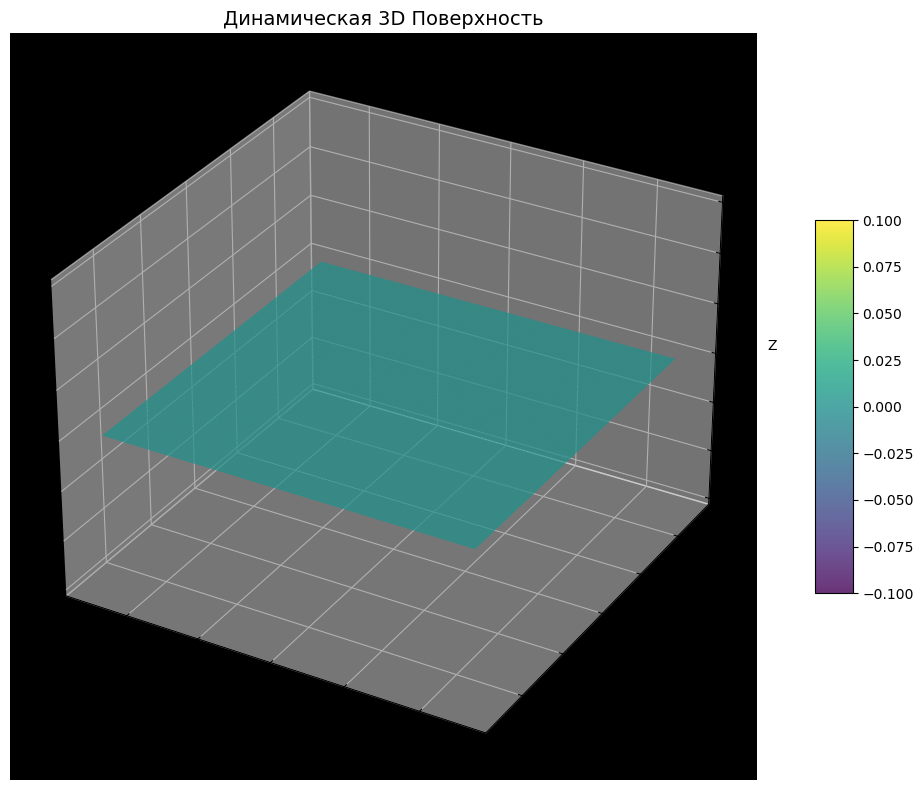

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
import matplotlib as mpl  # Импортируем основной модуль matplotlib

# Настройка фигуры и 3D осей
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('black')

# Параметры сетки
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

# Инициализация поверхности
surf = ax.plot_surface(X, Y, Z, cmap='viridis', rstride=1, cstride=1, 
                       alpha=0.8, antialiased=True, linewidth=0)

# Настройка визуализации
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Динамическая 3D Поверхность', fontsize=14)
ax.set_zlim(-3, 3)
fig.colorbar(surf, shrink=0.5, aspect=10)

# Функция генерации поверхности
def generate_surface(frame):
    time = frame * 0.1
    wave = np.sin(np.sqrt(X**2 + Y**2) - time)
    pulse = 0.5 * np.sin(2*X + time) * np.cos(2*Y - time)
    spiral = 0.7 * np.sin(X * np.cos(time*0.3) + Y * np.sin(time*0.3))
    return wave + pulse + spiral

# Функция обновления кадра
def update(frame):
    global surf
    
    # Удаляем предыдущую поверхность
    if surf:
        surf.remove()
    
    # Генерируем новую поверхность
    Z = generate_surface(frame)
    
    # ИСПРАВЛЕНИЕ: используем новый синтаксис для цветовых карт
    plasma_cmap = mpl.colormaps['plasma'].resampled(200)
    
    # Создаем новую поверхность с динамической цветовой картой
    surf = ax.plot_surface(X, Y, Z, cmap=plasma_cmap, 
                          rstride=2, cstride=2, 
                          alpha=0.9, 
                          linewidth=0.1,
                          antialiased=True)
    
    # Плавно меняем угол обзора
    ax.view_init(elev=30, azim=frame*0.5)
    
    # Динамическое обновление заголовка
    ax.set_title(f'Динамическая поверхность: Кадр {frame}', fontsize=14)
    
    return [surf]

# Создание анимации
ani = FuncAnimation(fig, update, frames=200, interval=50, blit=False)

plt.tight_layout()
plt.show()